In [1]:
!pip install torch transformers tqdm pandas numpy pyspark

In [6]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import Word2Vec
from pyspark.sql.functions import col, udf, size
from pyspark.sql.types import ArrayType, StringType
import re

# Initialize SparkSession
spark = SparkSession.builder \
    .appName("Word2Vec_Train_Test") \
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")

# =================== 1. Read Training and Test Datasets ===================
train_df = spark.read.option("header", True).option("inferSchema", True).csv("train_fixed_split.csv")
test_df = spark.read.option("header", True).option("inferSchema", True).csv("test_fixed_split.csv")

print("Training set size:", train_df.count())
print("Test set size:", test_df.count())

# =================== 2. Text Preprocessing Function ===================
def clean_text(text):
    if text is None:
        return []
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)   # Keep only letters and spaces
    words = text.split()
    return words

clean_udf = udf(clean_text, ArrayType(StringType()))

# Generate words column for both training and test sets
train_clean = train_df.withColumn("words", clean_udf(col("text")))
test_clean = test_df.withColumn("words", clean_udf(col("text")))

# Filter out empty arrays (size > 0)
train_clean = train_clean.filter(size(col("words")) > 0)
test_clean = test_clean.filter(size(col("words")) > 0)

print("Preprocessed training set rows:", train_clean.count())
print("Preprocessed test set rows:", test_clean.count())

# =================== 3. Train Word2Vec on Training Set ===================
word2vec = Word2Vec(
    vectorSize=100,      # Word vector dimension (adjustable)
    minCount=2,          # Words must appear at least 2 times in training set
    numPartitions=10,
    stepSize=0.025,
    maxIter=10,
    windowSize=5,
    inputCol="words",
    outputCol="features"
)

print("Starting Word2Vec model training on training set...")
model = word2vec.fit(train_clean)

# View word vector table (optional)
vocab = model.getVectors()
print("Number of word vectors trained:", vocab.count())
vocab.show(5, truncate=False)

# =================== 4. Transform Training and Test Sets Separately ===================
train_vectorized = model.transform(train_clean)
test_vectorized = model.transform(test_clean)

# Select required columns (text, label, features)
train_result = train_vectorized.select("text", "label", "features")
test_result = test_vectorized.select("text", "label", "features")

print("Training set vector result sample:")
train_result.show(5, truncate=80)
print("Test set vector result sample:")
test_result.show(5, truncate=80)

# =================== 5. Save Results ===================
train_result.write.mode("overwrite").parquet("output/word2vec_train.parquet")
test_result.write.mode("overwrite").parquet("output/word2vec_test.parquet")

print("Processing completed!")
print("Training set vectors saved to: output/word2vec_train.parquet")
print("Test set vectors saved to: output/word2vec_test.parquet")

spark.stop()

Training set size: 1190
Test set size: 298
Preprocessed training set rows: 1190
Preprocessed test set rows: 298
Starting Word2Vec model training on training set...
Number of word vectors trained: 6473
+-------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [7]:
# Cell: GloVe (Pre-trained Word Vectors) - Text Vectorization

import pandas as pd
import numpy as np
import re
import gzip
import requests
import os
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, ArrayType, FloatType
from pyspark.sql.functions import col, udf
from pyspark.ml.linalg import Vectors, VectorUDT

# Initialize SparkSession (get existing one if available, avoid duplicate creation)
spark = SparkSession.builder.getOrCreate()

# =================== 1. Read Training and Test Sets (using pandas for fast processing) ===================
train_df = pd.read_csv("train_fixed_split.csv")
test_df = pd.read_csv("test_fixed_split.csv")
print(f"Training set size: {len(train_df)}, Test set size: {len(test_df)}")

# =================== 2. Download and Load Pre-trained GloVe Word Vectors (6B, 100-dim) ===================
glove_url = "https://nlp.stanford.edu/data/glove.6B.zip"
glove_zip = "glove.6B.zip"
glove_file = "glove.6B.100d.txt"
glove_dir = "glove"

if not os.path.exists(glove_file):
    print("Downloading GloVe word vectors...")
    # Download zip file
    r = requests.get(glove_url, stream=True)
    with open(glove_zip, 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    # Extract
    import zipfile
    with zipfile.ZipFile(glove_zip, 'r') as zf:
        zf.extractall(glove_dir)
    # Move file to current directory
    import shutil
    shutil.move(os.path.join(glove_dir, glove_file), glove_file)
    shutil.rmtree(glove_dir)
    os.remove(glove_zip)
    print("Download completed.")

# Load word vectors into dictionary (word -> vector)
print("Loading GloVe word vectors...")
word2vec = {}
with open(glove_file, 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split()
        word = parts[0]
        vec = np.array(parts[1:], dtype=np.float32)
        word2vec[word] = vec
print(f"Loading completed, total {len(word2vec)} words.")

# =================== 3. Text Preprocessing Function ===================
def clean_text(text):
    if pd.isna(text):
        return []
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    words = text.split()
    return words

# =================== 4. Compute Document Average Vector ===================
def doc_to_avg_vector(words, word2vec, vector_dim=100):
    vectors = [word2vec[w] for w in words if w in word2vec]
    if not vectors:
        return np.zeros(vector_dim, dtype=np.float32)
    return np.mean(vectors, axis=0)

# Process dataset
def process_dataframe(df, word2vec):
    texts = df['text'].tolist()
    labels = df['label'].tolist()
    vectors = []
    for text in texts:
        words = clean_text(text)
        vec = doc_to_avg_vector(words, word2vec)
        vectors.append(vec)
    return texts, labels, vectors

print("Processing training set...")
train_texts, train_labels, train_vecs = process_dataframe(train_df, word2vec)
print("Processing test set...")
test_texts, test_labels, test_vecs = process_dataframe(test_df, word2vec)

# =================== 5. Convert to Spark DataFrame and Save (consistent with Word2Vec output format) ===================
# Convert numpy arrays to pyspark.ml.linalg.Vector
train_vectors_spark = [Vectors.dense(v) for v in train_vecs]
test_vectors_spark = [Vectors.dense(v) for v in test_vecs]

# Create Spark DataFrame
train_spark_df = spark.createDataFrame(
    [(text, int(label), vec) for text, label, vec in zip(train_texts, train_labels, train_vectors_spark)],
    schema=StructType([
        StructField("text", StringType(), True),
        StructField("label", IntegerType(), True),
        StructField("features", VectorUDT(), True)
    ])
)

test_spark_df = spark.createDataFrame(
    [(text, int(label), vec) for text, label, vec in zip(test_texts, test_labels, test_vectors_spark)],
    schema=StructType([
        StructField("text", StringType(), True),
        StructField("label", IntegerType(), True),
        StructField("features", VectorUDT(), True)
    ])
)

# Save as Parquet
train_spark_df.write.mode("overwrite").parquet("output/glove_train.parquet")
test_spark_df.write.mode("overwrite").parquet("output/glove_test.parquet")

print("Training set GloVe vectors saved to: output/glove_train.parquet")
print("Test set GloVe vectors saved to: output/glove_test.parquet")

# Display samples
print("Sample data (first 3 rows of training set):")
train_spark_df.show(3, truncate=80)

spark.stop()

Training set size: 1190, Test set size: 298
Loading GloVe word vectors...
Loading completed, total 400000 words.
Processing training set...
Processing test set...
Training set GloVe vectors saved to: output/glove_train.parquet
Test set GloVe vectors saved to: output/glove_test.parquet
Sample data (first 3 rows of training set):
+--------------------------------------------------------------------------------+-----+--------------------------------------------------------------------------------+
|                                                                            text|label|                                                                        features|
+--------------------------------------------------------------------------------+-----+--------------------------------------------------------------------------------+
|this is the greatest album of all time if you dont give this stars then somet...|    1|[-0.1279807686805725,0.28847217559814453,0.527188241481781,-0.3763820528

In [8]:
# Cell: BERT (Pre-trained) - Text Vectorization

import torch
import numpy as np
import pandas as pd
import re
from transformers import BertTokenizer, BertModel
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, IntegerType
from pyspark.ml.linalg import Vectors, VectorUDT
from tqdm import tqdm

# Initialize SparkSession
spark = SparkSession.builder.getOrCreate()

# =================== 1. Load Data ===================
train_df = pd.read_csv("train_fixed_split.csv")
test_df = pd.read_csv("test_fixed_split.csv")
print(f"Training set size: {len(train_df)}, Test set size: {len(test_df)}")

# =================== 2. Load BERT Model and Tokenizer ===================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased').to(device)
model.eval()  # Inference mode

# =================== 3. Text Preprocessing (consistent with previous methods) ===================
def clean_text(text):
    if pd.isna(text):
        return ""
    # For BERT effectiveness, original case is preserved (bert-base-uncased handles case itself, but unified lowercase is also fine)
    # Here, for consistency with Word2Vec/GloVe preprocessing, lowercase and remove punctuation is used, but note BERT is case-insensitive
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    return text

# =================== 4. Batch Extract CLS Vectors ===================
def get_bert_vectors(texts, batch_size=32, max_length=128):
    """
    Input: list of strings
    Output: numpy array (n_samples, 768)
    """
    vectors = []
    # Use tqdm to show progress
    for i in tqdm(range(0, len(texts), batch_size), desc="BERT encoding"):
        batch_texts = texts[i:i+batch_size]
        # Tokenize and pad/truncate
        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors='pt'
        )
        input_ids = encoded['input_ids'].to(device)
        attention_mask = encoded['attention_mask'].to(device)

        with torch.no_grad():
            outputs = model(input_ids, attention_mask=attention_mask)
            # Use CLS vector (shape: batch_size, 768)
            cls_vectors = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        vectors.append(cls_vectors)
    return np.vstack(vectors)

# Clean text
print("Preprocessing training set texts...")
train_texts_clean = [clean_text(t) for t in train_df['text']]
print("Preprocessing test set texts...")
test_texts_clean = [clean_text(t) for t in test_df['text']]

# Extract vectors
print("Extracting BERT vectors for training set...")
train_vecs = get_bert_vectors(train_texts_clean)
print("Extracting BERT vectors for test set...")
test_vecs = get_bert_vectors(test_texts_clean)

print(f"Training set vector dimension: {train_vecs.shape[1]}")
print(f"Test set vector dimension: {test_vecs.shape[1]}")

# =================== 5. Convert to Spark DataFrame and Save ===================
# Convert numpy arrays to pyspark.ml.linalg.Vector
train_vectors_spark = [Vectors.dense(v) for v in train_vecs]
test_vectors_spark = [Vectors.dense(v) for v in test_vecs]

# Create Spark DataFrame
train_spark_df = spark.createDataFrame(
    [(text, int(label), vec) for text, label, vec in zip(train_df['text'], train_df['label'], train_vectors_spark)],
    schema=StructType([
        StructField("text", StringType(), True),
        StructField("label", IntegerType(), True),
        StructField("features", VectorUDT(), True)
    ])
)

test_spark_df = spark.createDataFrame(
    [(text, int(label), vec) for text, label, vec in zip(test_df['text'], test_df['label'], test_vectors_spark)],
    schema=StructType([
        StructField("text", StringType(), True),
        StructField("label", IntegerType(), True),
        StructField("features", VectorUDT(), True)
    ])
)

# Save as Parquet
train_spark_df.write.mode("overwrite").parquet("output/bert_train.parquet")
test_spark_df.write.mode("overwrite").parquet("output/bert_test.parquet")

print("Training set BERT vectors saved to: output/bert_train.parquet")
print("Test set BERT vectors saved to: output/bert_test.parquet")

# Display samples
print("Sample data (first 3 rows of training set):")
train_spark_df.show(3, truncate=80)

spark.stop()

Training set size: 1190, Test set size: 298
Using device: cpu


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Preprocessing training set texts...
Preprocessing test set texts...
Extracting BERT vectors for training set...


BERT encoding: 100%|██████████| 38/38 [08:05<00:00, 12.77s/it]


Extracting BERT vectors for test set...


BERT encoding: 100%|██████████| 10/10 [01:55<00:00, 11.58s/it]


Training set vector dimension: 768
Test set vector dimension: 768
Training set BERT vectors saved to: output/bert_train.parquet
Test set BERT vectors saved to: output/bert_test.parquet
Sample data (first 3 rows of training set):
+--------------------------------------------------------------------------------+-----+--------------------------------------------------------------------------------+
|                                                                            text|label|                                                                        features|
+--------------------------------------------------------------------------------+-----+--------------------------------------------------------------------------------+
|this is the greatest album of all time if you dont give this stars then somet...|    1|[-0.15881213545799255,0.1618344783782959,0.4896301031112671,0.300170183181762...|
|english isnt my main language sorry if i made a few mistakes nntheres somethi...|    0|[-0

Using SparkSession: <pyspark.sql.session.SparkSession object at 0x78711f08d820>
Loading Word2Vec vectors...
  Training set: 1190, Test set: 298
  Word2Vec - Acc: 0.9195, F1: 0.9039, AUC: 0.7322
Loading GloVe vectors...
  Training set: 1190, Test set: 298
  GloVe - Acc: 0.9060, F1: 0.8914, AUC: 0.7927
Loading BERT vectors...
  Training set: 1190, Test set: 298
  BERT - Acc: 0.8926, F1: 0.8881, AUC: 0.7310

========== Final Comparison Results ==========
   model  accuracy       f1      auc
Word2Vec  0.919463 0.903885 0.732208
   GloVe  0.906040 0.891387 0.792731
    BERT  0.892617 0.888125 0.730991


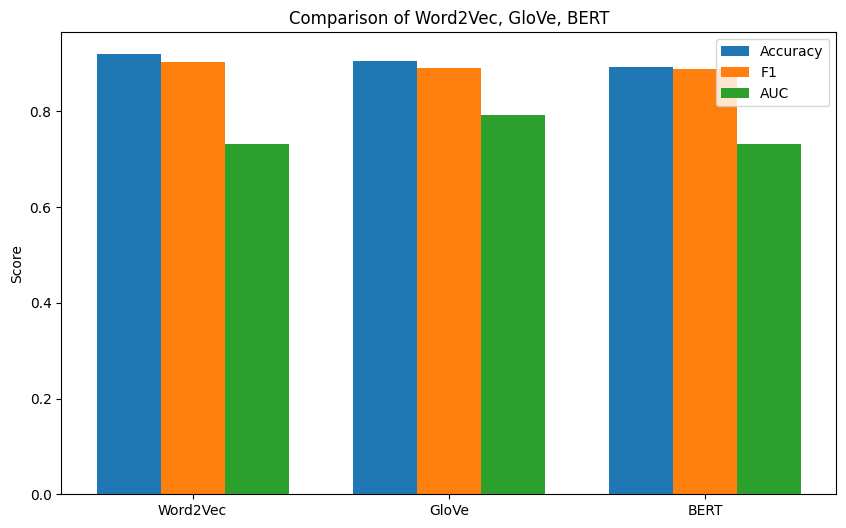

In [9]:
# Cell: Compare Word2Vec, GloVe, BERT Performance on Sentiment Classification

import os
from pyspark.sql import SparkSession
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator

# Get current active SparkSession (avoid creating duplicate)
spark = SparkSession.getActiveSession()
if spark is None:
    spark = SparkSession.builder.appName("ModelComparison").getOrCreate()
print(f"Using SparkSession: {spark}")

# =================== 1. Define Model Paths (modify according to actual save locations) ===================
models_config = {
    "Word2Vec": {
        "train": "output/word2vec_train.parquet",
        "test": "output/word2vec_test.parquet"
    },
    "GloVe": {
        "train": "output/glove_train.parquet",
        "test": "output/glove_test.parquet"
    },
    "BERT": {
        "train": "output/bert_train.parquet",
        "test": "output/bert_test.parquet"
    }
}

# =================== 2. Evaluation Function ===================
def evaluate_model(train_df, test_df, model_name, feature_col="features"):
    lr = LogisticRegression(featuresCol=feature_col, labelCol="label", maxIter=10)
    model = lr.fit(train_df)
    predictions = model.transform(test_df)

    acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy").evaluate(predictions)
    f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1").evaluate(predictions)
    auc = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC").evaluate(predictions)

    return {"model": model_name, "accuracy": acc, "f1": f1, "auc": auc}

# =================== 3. Loop Evaluation ===================
results = []

for name, paths in models_config.items():
    print(f"Loading {name} vectors...")
    train_path = paths["train"]
    test_path = paths["test"]

    # Check if files exist
    if not os.path.exists(train_path) or not os.path.exists(test_path):
        print(f"  {name} files do not exist, skipping.")
        continue

    try:
        train_df = spark.read.parquet(train_path)
        test_df = spark.read.parquet(test_path)
        train_count = train_df.count()
        test_count = test_df.count()
        print(f"  Training set: {train_count}, Test set: {test_count}")

        metrics = evaluate_model(train_df, test_df, name)
        results.append(metrics)
        print(f"  {name} - Acc: {metrics['accuracy']:.4f}, F1: {metrics['f1']:.4f}, AUC: {metrics['auc']:.4f}")
    except Exception as e:
        print(f"  {name} processing failed: {e}")

# =================== 4. Output Comparison Results ===================
print("\n========== Final Comparison Results ==========")
if results:
    import pandas as pd
    pd_results = pd.DataFrame(results)
    print(pd_results.to_string(index=False))

    # Plot bar chart
    try:
        import matplotlib.pyplot as plt
        import numpy as np
        x = np.arange(len(results))
        width = 0.25
        fig, ax = plt.subplots(figsize=(10,6))
        ax.bar(x - width, [r['accuracy'] for r in results], width, label='Accuracy')
        ax.bar(x, [r['f1'] for r in results], width, label='F1')
        ax.bar(x + width, [r['auc'] for r in results], width, label='AUC')
        ax.set_xticks(x)
        ax.set_xticklabels([r['model'] for r in results])
        ax.set_ylabel('Score')
        ax.set_title('Comparison of Word2Vec, GloVe, BERT')
        ax.legend()
        plt.show()
    except ImportError:
        print("matplotlib not installed, skipping plot.")
else:
    print("No models successfully loaded, please check file paths.")

# Note: Do not stop SparkSession